#### Name: Solutions

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

In [6]:
# put all import statements here
import numpy as np
from gaussxw import gaussxw
import matplotlib.pyplot as plt

## Gaussian Quadrature 1

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ **(a)** Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

**(b)** Repeat the evaluation with 2𝑁 points and evaluate the error.  

**(c)** Compare these results with your results for both the trapezoidal and Simpson’s rules


In [12]:
# define function 
def f(x):
    return np.sin(x)/np.log(x)

In [9]:
## (a) For N = 10 points 

# define variables 
N = 10
a = 1.1
b = 10.1

# calculate the sample points and weights
x,w = gaussxw(N)


# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w
print(xp)
print(wp)

# perform integration
s = 0.0
for k in range(N):
    s += wp[k]*f(xp[k])
    
print(s)

[9.98257938 9.49278515 8.65734306 7.55027927 6.26993453 4.93006547
 3.64972073 2.54265694 1.70721485 1.21742062]
[0.30002105 0.67253107 0.98588863 1.21170024 1.32985901 1.32985901
 1.21170024 0.98588863 0.67253107 0.30002105]
2.7929415637241966


In [10]:
## (a) For N = 20 points 
N = 20
a = 1.1
b = 10.1

# calculate the sample points and weights
x,w = gaussxw(N)


# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w
print(xp)
print(wp)

# perform integration
s2 = 0.0
for k in range(N):
    s2 += wp[k]*f(xp[k])
    
print(s2)
print("error = ", np.abs(s2-s))
perc_Err = np.abs(s2-s)/2.84895*100
print("the percent error is = ", perc_Err)

[10.0690787   9.93787367  9.70505493  9.37602637  8.95849358  8.46224156
  7.89890151  7.2816774   6.62503633  5.94436935  5.25563065  4.57496367
  3.9183226   3.30109849  2.73775844  2.24150642  1.82397363  1.49494507
  1.26212633  1.1309213 ]
[0.07926303 0.18270643 0.28202422 0.37474534 0.45868554 0.53187539
 0.59259887 0.63943249 0.67127844 0.68739024 0.68739024 0.67127844
 0.63943249 0.59259887 0.53187539 0.45868554 0.37474534 0.28202422
 0.18270643 0.07926303]
2.848058807728295
error =  0.05511724400409834
the percent error is =  1.9346511523227274


##### (c) compare: 

this has a larger error than either of the previous methods. However, this uses 10 and 20 points, while Trapezoidal used N = 100 & 200 to an error of 0.01310, and Simpson's uses N = 50 and 100 to get an error of 0.002957748244844863. I'm going to try 20 and 40 points to see how it improves - this drastically imrpoved with still fewer points than Simpson's or Trapezoidal. 

In [11]:
# N = 40 points 

# define variables 
N = 40
a = 1.1
b = 10.1

# calculate the sample points and weights
x,w = gaussxw(N)


# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w
print(xp)
print(wp)

# perform integration
s3 = 0.0
for k in range(N):
    s3 += wp[k]*f(xp[k])
    
print(s3)
print("error = ", np.abs(s3-s2))
perc_Err = np.abs(s3-s2)/2.84895*100
print("the percent error is = ", perc_Err)

[10.09206969 10.05826807  9.99766977  9.91062569  9.79765764  9.65944463
  9.49681776  9.31075504  9.10237543  8.87293215  8.62380508  8.3564925
  8.07260206  7.77384111  7.46200642  7.13897341  6.80668483  6.46713911
  6.12237832  5.77447588  5.42552412  5.07762168  4.73286089  4.39331517
  4.06102659  3.73799358  3.42615889  3.12739794  2.8435075   2.57619492
  2.32706785  2.09762457  1.88924496  1.70318224  1.54055537  1.40234236
  1.28937431  1.20233023  1.14173193  1.10793031]
[0.02034575 0.04724228 0.07389476 0.10010632 0.12571653 0.15057088
 0.17451976 0.19741909 0.21913113 0.23952531 0.25847896 0.27587809
 0.29161806 0.30560421 0.31775241 0.32798962 0.33625426 0.34249663
 0.34667918 0.34877677 0.34877677 0.34667918 0.34249663 0.33625426
 0.32798962 0.31775241 0.30560421 0.29161806 0.27587809 0.25847896
 0.23952531 0.21913113 0.19741909 0.17451976 0.15057088 0.12571653
 0.10010632 0.07389476 0.04724228 0.02034575]
2.8489495642908023
error =  0.0008907565625073666
the percent err

## Gaussian Quadrature 2

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


**(a)** First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

**(b)** Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

**(c)** Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


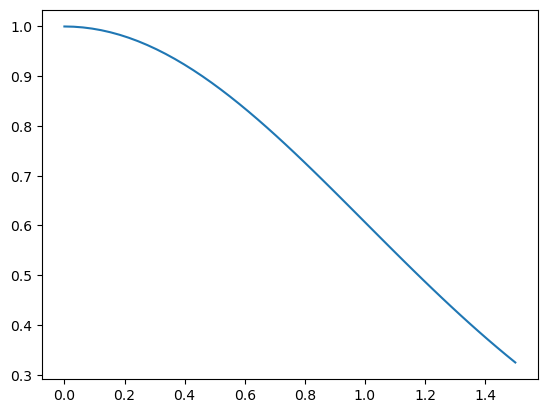

In [15]:
# part a - make a plot of the function
x = np.linspace(0,1.5,50)
y = np.exp(-x**2/2)
plt.plot(x,y)

Yes, this is a smooth function, so we do expect GQ to be a good analysis method for this integral 

In [16]:
# part (b) - determine sample points values 

N = 2
a = 0.0
b = 1.5

# calculate the sample points and weights
x,w = gaussxw(N)

print(x)
print(w)

# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w
print(xp)
print(wp)

[ 0.57735027 -0.57735027]
[1. 1.]
[1.1830127 0.3169873]
[0.75 0.75]


In [17]:
# part (c)
# define function 
def f(x):
    return np.exp(-x**2/2)

# perform integration
s = 0.0
for k in range(N):
    s += wp[k]*f(xp[k])
    
print(s)

1.085779080189856


In [18]:
# part d

N = 4
a = 0.0
b = 1.5

# calculate the sample points and weights
x,w = gaussxw(N)

# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# perform integration
s_N4 = 0.0
for k in range(N):
    s_N4 += wp[k]*f(xp[k])
    
print(s_N4)
print("the error is = ", np.abs(s_N4 - s))

1.0858542826593225
the error is =  7.520246946657316e-05


In [19]:
# error was still too big, so do one more interation 

N = 8
a = 0.
b = 1.5

# calculate the sample points and weights
x,w = gaussxw(N)

# map to required integration domain 
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# perform integration
s_N8 = 0.0
for k in range(N):
    s_N8 += wp[k]*f(xp[k])
    
print(s_N8)
print("the error is = ", np.abs(s_N8 - s_N4))

1.085853317666042
the error is =  9.64993280394566e-07


#### part (d) result: 

It took $N=8$ to achieve the desired accuracy 

## Gaussian Quadrature 3 (25 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$ starting with $N=5$ sample points & doubling until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 

You may want to make a Gaussian Quadrature function that you can call on for repeat use and a `while` loop may be helpful to achieve the accuracy you want. 

(hint: a graph of the function might help you to understand what is going on)

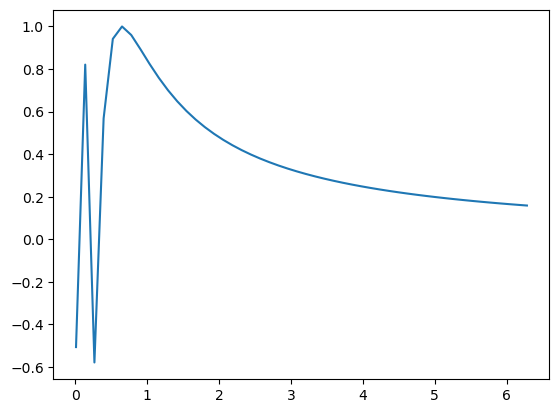

In [2]:
# make a plot of the function to see if smooth
x = np.linspace(0.01,2*np.pi,50)
y = np.sin(1/x)
plt.plot(x,y)

This is clearly not a smooth function - probably will not result in an accurate evaluation in a few number of steps 

In [7]:
## let's do this with a while loop: 

# define function that want to integrate 
def f(x_new):
    return np.sin(1/x_new)

# define gaussian quadrature function 
def gauss_quad(N,a,b):
    x,w = gaussxw(N)
    xp = 0.5*(b-a)*x + 0.5*(b+a)
    wp = 0.5*(b-a)*w
    s=0
    for k in range(N):
        s += wp[k]*f(xp[k])
    return s

# set problem variables/paramters 
N = 5
a = 0.01
b = 2*np.pi
# set desired accuracy 
accuracy = 1e-5

# set starting error and integral value 
err = 1000
I_before = 300
# while loop that keeps integrating until accuracy achieved 
while err > accuracy:
    I = gauss_quad(N,a,b)
    err = np.abs(I-I_before)
    print("Integral approxm = ", I, "for N = ", N)
    print("error in this = ", err)
    I_before = I
    N = N*2

Integral approxm =  1.8330645439986597 for N =  5
error in this =  298.16693545600134
Integral approxm =  2.1795836819165104 for N =  10
error in this =  0.3465191379178507
Integral approxm =  2.3948584800669477 for N =  20
error in this =  0.21527479815043726
Integral approxm =  2.3031574328396247 for N =  40
error in this =  0.09170104722732297
Integral approxm =  2.232173285628022 for N =  80
error in this =  0.07098414721160262
Integral approxm =  2.2669528361572295 for N =  160
error in this =  0.03477955052920745


KeyboardInterrupt: 

Integral approxm =  1.8330645439986575 for N =  5
error in this =  298.16693545600134
Integral approxm =  2.179583681916516 for N =  10
error in this =  0.3465191379178587
Integral approxm =  2.3948584800669415 for N =  20
error in this =  0.21527479815042527
Integral approxm =  2.3031574328396243 for N =  40
error in this =  0.0917010472273172
Integral approxm =  2.2321732856280248 for N =  80
error in this =  0.07098414721159951
Integral approxm =  2.2669528361572278 for N =  160
error in this =  0.03477955052920301
Integral approxm =  2.2647387759747897 for N =  320
error in this =  0.0022140601824380823
Integral approxm =  2.2626857715635325 for N =  640
error in this =  0.00205300441125722
Integral approxm =  2.262685754589717 for N =  1280
error in this =  1.6973815242238288e-08

In [24]:
### if had done with x = 0.0 to x = 2pi
## let's do this with a while loop: 

def f(x_new):
    return np.sin(1/x_new)

def gauss_quad(N,a,b):
    x,w = gaussxw(N)
    xp = 0.5*(b-a)*x + 0.5*(b+a)
    wp = 0.5*(b-a)*w
    s=0
    for k in range(N):
        s += wp[k]*f(xp[k])
    return s

N = 5
a = 0.0
b = 2*np.pi
accuracy = 1e-5

err = 1000
I_before = 300
while err > accuracy:
    I = gauss_quad(N,a,b)
    err = np.abs(I-I_before)
    print("Integral approxm = ", I, "for N = ", N)
    print("error in this = ", err)
    I_before = I
    N = N*2

Integral approxm =  1.763709471325411 for N =  5
error in this =  298.2362905286746
Integral approxm =  2.3054382057196636 for N =  10
error in this =  0.5417287343942527
Integral approxm =  2.3519375684248947 for N =  20
error in this =  0.04649936270523103
Integral approxm =  2.344146978170413 for N =  40
error in this =  0.0077905902544817
Integral approxm =  2.2306454586781235 for N =  80
error in this =  0.11350151949228948
Integral approxm =  2.243927697966069 for N =  160
error in this =  0.013282239287945696
Integral approxm =  2.2551435512784717 for N =  320
error in this =  0.01121585331240249
Integral approxm =  2.2645503408940257 for N =  640
error in this =  0.009406789615554079
Integral approxm =  2.260608032365327 for N =  1280
error in this =  0.0039423085286989235
Integral approxm =  2.2633840550241 for N =  2560
error in this =  0.0027760226587729697
Integral approxm =  2.2632962874918916 for N =  5120
error in this =  8.776753220818279e-05
Integral approxm =  2.26289

## Infinite integrals (25 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

We will use: 
$$ x = \frac{z}{1-z} $$ and $$dx = \frac{dz}{(1-z)^2} $$
so $$ I = \int_{0}^{\infty} \frac{x^2}{\sqrt{x}}e^{-x}dx = \int_0^1 \frac{(\frac{z}{1-z})^2}{\sqrt{\frac{z}{1-z}}}e^{-\frac{z}{1-z}} \frac{dz}{(1-z)^2} $$

#### Step 2: Define the function to use in the next step for integration

In [5]:
def f(z):
    # define the x transformation 
    x = z/(1-z)
    # define the dx transformation 
    dx = 1/(1-z)**2
    #return the overall function 
    return (x**2/np.sqrt(x))*np.exp(-x)*dx

#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

In [6]:
# define number of points and limits of integration
N = 20
a = 0.0
b = 1.0
# calculate initial sample points and weights
x,w = gaussxw(N)
# remap since 0 to 1, not -1 to 1
xk = 0.5*(b-a)*x+0.5*(b+a)
wk = 0.5*(b-a)*w

# evaluate gaussian quadrature with weights and the value of the function above at each sample point
s = 0.0
for k in range(N):
    s += wk[k]*f(xk[k])
print(s)

# print result and compare to true value
print("the actual value should be", 3*np.sqrt(np.pi)/4)
print("the true error is", np.abs(3*np.sqrt(np.pi)/4-s))

1.3293510592219413
the actual value should be 1.329340388179137
the true error is 1.0671042804277775e-05


#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

As we can see above, the result and true value only differ by $1\times10^{-5}$, which seems quite accurate with only 20 sample points. 

In this program, we took the basics that were taught in class, and really the only thing that changed was the function used in the calculation. This makes it really easy to apply Gaussian quadrature to all sorts of integrals. 

## Multiple integrals (25 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/m$^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you can use some of my latex coding from the cell above this)

$$M = \iint_R \sigma(x,y) \hspace{1mm} dx \hspace{1mm}dy = \int_0^2 \int_0^3 (\sin(\pi x)+1)y \hspace{1mm} dx \hspace{1mm}dy$$

#### Step 2: Define the function to use in the next step for integration

In [7]:
def f(x,y):
    return (np.sin(np.pi*x)+1)*y

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

In [8]:
# use gaussian quadrature for 100 points
# for double integral, need to define both limits of integration
N = 100
ax = 0
bx = 3
ay = 0
by = 2

# can use same initial sample points for each part of integral
x,w = gaussxw(N)
# remap since 0 to 1, not -1 to 1
xx = 0.5*(bx-ax)*x+0.5*(bx+ax)
wx = 0.5*(bx-ax)*w
# remap y integral too
xy = 0.5*(by-ay)*x+0.5*(by+ay)
wy = 0.5*(by-ay)*w

# evaluate double Gaussian quadrature 
s = 0.0
for i in range(N):
    for j in range(N):
        s += wx[i]*wy[j]*f(xx[i], xy[j])
print(s)

# print result and compare to true value
print("the actual value should be", 4/np.pi +6)
print("the true error is", np.abs(4/np.pi +6-s))

7.273239544735162
the actual value should be 7.273239544735163
the true error is 8.881784197001252e-16


#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$

With 100 sample points, we are able to approximate a double integral with accuracy of 1\times10^{-16}$, so quite accurately!

In this program, we took the basics that were taught in class, and the changes that had to be made were the function used in the calculation and applying gaussian quadrature to both the x and y integrals. This makes it really easy to apply Gaussian quadrature to all sorts of integrals. 